# Fintech P1: Week 1: Linear Models & The Risk of Overfitting
# A (Finance) Tale of Linear Regression, Ridge, and Lasso


This notebook demonstrates the core concepts of Week 1. We will not just learn how to implement linear models, but why they are used—and feared—in finance and economics.

We will cover:
*   The Problem: Simulating a noisy economic cycle.
*   The "Too Simple" Model: Why a basic Linear Regression fails.
*   The "Perfect Backtest" Trap: How overfitting creates a high-risk, dangerous model.
*   The Stability Tool: Using Ridge Regression to manage risk and create a robust model.
*   The Insight Tool: Using Lasso Regression to gain insight and build an interpretable model.

## Part 1: The "Market Cycle" Dataset
Let's imagine the data we are about to create isn't just a mathematical function. It's a seasonal economic indicator or a market cycle (e.g., quarterly earnings, commodity prices, etc.).

The blue dots are the real, noisy, daily data points.

**Our Goal**: Build a model that can understand this cycle. A good model could be used for a profitable trading strategy or for making accurate economic forecasts.

### Library Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

### Function to simulate

Create a function of X to simulate a dataset:
$$f(x)=\cos(\frac{3}{2}\pi x)$$

In [2]:
def true_fun(X):
    return np.cos(1.5 * np.pi * X)


np.random.seed(100)
n_samples = 50



### Simulation

We need three separate things, and it is worth being precise about them because students
(and practitioners) routinely collapse them into one:

*   a **training sample** - the noisy points the model is allowed to learn from;
*   a **test sample** - *different* points, drawn from the same process and carrying their own
    noise, which the model never sees during fitting;
*   a **smooth grid** of the true function, used only to draw the underlying cycle on charts.

The third one is a luxury of simulated data: in real life the true function does not exist in
a column of your dataframe. If we scored our models against it we would be marking our own
homework against the answer sheet, and the test error would look far better than anything
achievable on real data.

In [3]:
# 1. The TRAINING sample - what we actually observe, noise included
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.2

# 2. A genuine HELD-OUT TEST sample - new draws from the same process,
#    with their own noise. This is what "unseen data" means.
rng_test = np.random.RandomState(7)
X_test = np.sort(rng_test.rand(200))
y_test = true_fun(X_test) + rng_test.randn(200) * 0.2

# 3. A smooth grid used ONLY for drawing the true curve on the charts.
#    It is not data and we never score against it.
X_curve = np.linspace(0, 1, 100)
y_curve = true_fun(X_curve)

print(f"train: {len(X)} noisy points")
print(f"test : {len(X_test)} noisy points, held out")
print(f"noise sd = 0.2  ->  no model can do better than RMSE = 0.20 on the test set")

train: 50 noisy points
test : 200 noisy points, held out
noise sd = 0.2  ->  no model can do better than RMSE = 0.20 on the test set


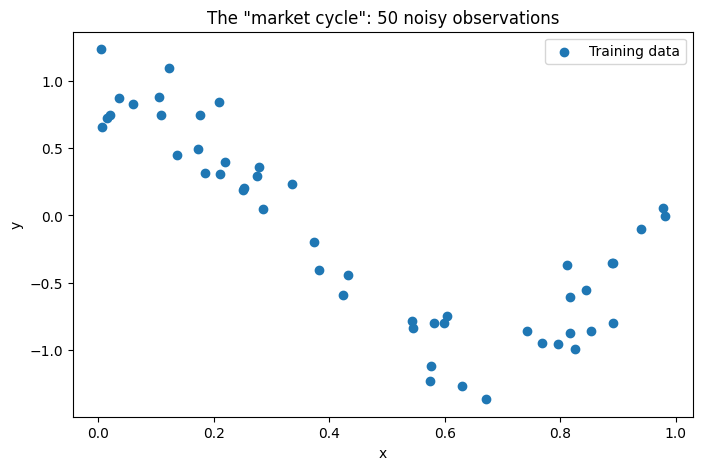

In [4]:
plt.figure(figsize=[8, 5])
plt.scatter(X, y, label='Training data')
plt.xlabel('x'); plt.ylabel('y')
plt.title('The "market cycle": 50 noisy observations')
plt.legend()
plt.show()

## Part 2: The "Too Simple" Model (Standard Linear Regression)

Let's start with our most basic tool: a standard Linear Regression model. We will try to fit a straight line to our "market cycle" data.

### Library Import

In [5]:
from math import sqrt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# We keep results in dictionaries keyed by model name rather than in lists.
# Re-running a cell then OVERWRITES that model's row instead of silently
# appending a duplicate - which matters, because we will re-run these cells.
scores = {}
coef_rows = {}


def score(name, train_pred, test_pred):
    """Score a model on the training sample and on the held-out test sample."""
    scores[name] = {
        'Model': name,
        'R-squared train': r2_score(y, train_pred),
        'R-squared test': r2_score(y_test, test_pred),
        'RMSE train': sqrt(mean_squared_error(y, train_pred)),
        'RMSE test': sqrt(mean_squared_error(y_test, test_pred)),
        'MAE train': mean_absolute_error(y, train_pred),
        'MAE test': mean_absolute_error(y_test, test_pred),
    }
    return pd.DataFrame(scores.values())


def record_coefs(name, estimator):
    """Store the fitted coefficients, whether estimator is a model or a pipeline."""
    model = estimator.steps[-1][1] if hasattr(estimator, 'steps') else estimator
    row = {'Model': name, 'Intercept': model.intercept_}
    for j, c in enumerate(model.coef_, start=1):
        row[f'X^{j}'] = c
    coef_rows[name] = row

### Fitting the Linear Regression

In [6]:
linear = LinearRegression()
linear.fit(X.reshape(-1, 1), y)

linear_train_prediction = linear.predict(X.reshape(-1, 1))
linear_test_prediction = linear.predict(X_test.reshape(-1, 1))
linear_curve = linear.predict(X_curve.reshape(-1, 1))

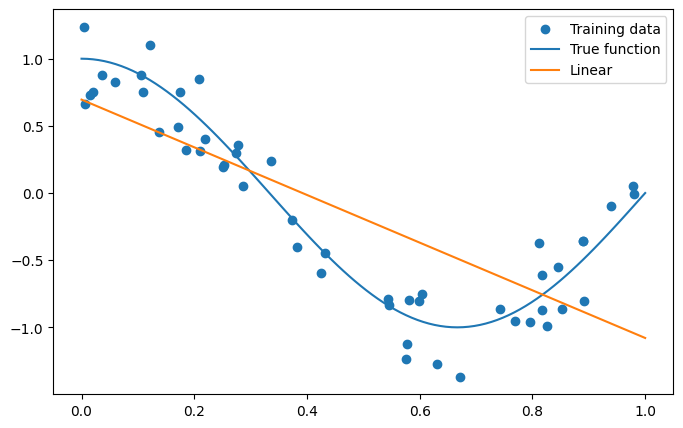

In [7]:
plt.figure(figsize=[8, 5])
plt.scatter(X, y, label='Training data')
plt.plot(X_curve, y_curve, label='True function')
plt.plot(X_curve, linear_curve, label='Linear')
plt.legend()
plt.show()

### Calculating performance metrics

In [8]:
score('Linear', linear_train_prediction, linear_test_prediction)

,Model,R-squared train,R-squared test,RMSE train,RMSE test,MAE train,MAE test
0,Linear,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012


**The Verdict: A Failed Model**

As we can see, the straight line completely misses the point. It fails to capture the seasonal "cycle" in our data.

In financial terms, this model is too simple (it has high bias). It sees limited pattern (only the downward trend but not the reverse after) and would be completely useless for trading or forecasting.

## Part 3: The "Perfect Backtest" Trap (Overfitting)
"Okay," a junior analyst says, "if a simple line is bad, let's use a complex line!"

They use a high-degree polynomial (e.g., 15 or 30 degrees) to create new, complex features. This allows the model to "wiggle" as much as it needs to fit the data perfectly.

Let's see what happens.



### Library Import

In [9]:
from sklearn.preprocessing import PolynomialFeatures


### Polynomial Transformation

In [10]:
# include_bias=False: PolynomialFeatures would otherwise add a constant column,
# and LinearRegression already fits its own intercept. Keeping both gives you a
# useless "X^0" column whose coefficient is always 0.
poly_transform = PolynomialFeatures(degree=15, include_bias=False)

# fit_transform on the TRAINING inputs only, then transform everything else
X_poly = poly_transform.fit_transform(X.reshape(-1, 1))
X_poly_test = poly_transform.transform(X_test.reshape(-1, 1))
X_poly_curve = poly_transform.transform(X_curve.reshape(-1, 1))

In [11]:
linear_poly = LinearRegression()
linear_poly.fit(X_poly, y)

linear_poly_train_prediction = linear_poly.predict(X_poly)
linear_poly_test_prediction = linear_poly.predict(X_poly_test)
linear_poly_curve = linear_poly.predict(X_poly_curve)

print(f"largest coefficient in this model: {np.abs(linear_poly.coef_).max():,.0f}")

largest coefficient in this model: 1,254,020,429


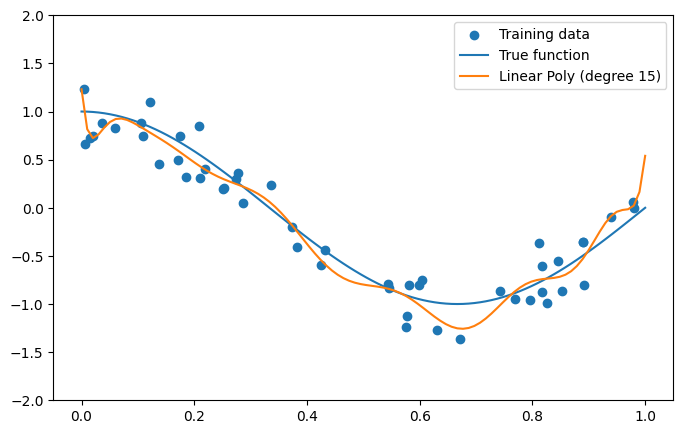

In [12]:
plt.figure(figsize=[8, 5])
plt.scatter(X, y, label='Training data')
plt.plot(X_curve, y_curve, label='True function')
plt.plot(X_curve, linear_poly_curve, label='Linear Poly (degree 15)')
plt.ylim(-2, 2)
plt.legend()
plt.show()

### Calculating performance metrics

In [13]:
score('Linear Poly', linear_poly_train_prediction, linear_poly_test_prediction)

,Model,R-squared train,R-squared test,RMSE train,RMSE test,MAE train,MAE test
0,Linear,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
1,Linear Poly,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237


### Plotting based on different degrees

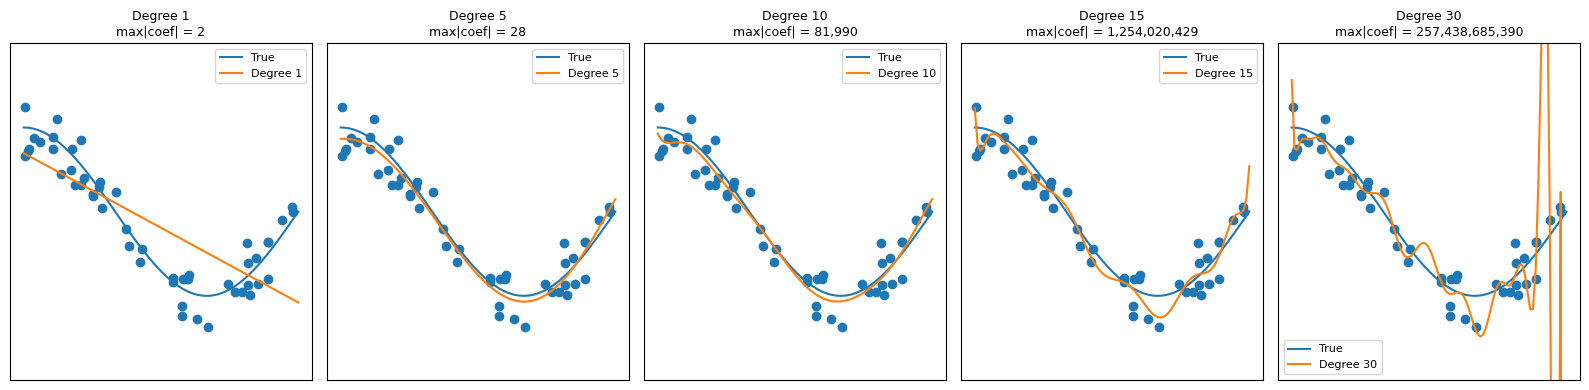

In [14]:
degrees = [1, 5, 10, 15, 30]

plt.figure(figsize=(16, 4))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    # Transform - fitted on the training inputs only
    pf = PolynomialFeatures(degree=degree, include_bias=False)
    Xd = pf.fit_transform(X.reshape(-1, 1))
    Xd_test = pf.transform(X_test.reshape(-1, 1))
    Xd_curve = pf.transform(X_curve.reshape(-1, 1))

    # Fit
    model = LinearRegression()
    model.fit(Xd, y)

    # Score on the training sample and on the held-out test sample
    name = f'Poly degree {degree}'
    score(name, model.predict(Xd), model.predict(Xd_test))
    record_coefs(name, model)

    # Plot
    plt.scatter(X, y)
    plt.plot(X_curve, y_curve, label='True')
    plt.plot(X_curve, model.predict(Xd_curve), label=f'Degree {degree}')
    plt.ylim(-2, 2)
    plt.legend(fontsize=8)
    plt.title(f'Degree {degree}\nmax|coef| = {np.abs(model.coef_).max():,.0f}', fontsize=9)

plt.tight_layout()
plt.show()

**The Verdict: A DANGEROUS Model**

Now look at the table below, and read the two R-squared columns *against each other*.

Up to degree 10, adding complexity helps on both. From degree 15 onwards the two columns
start moving in **opposite directions**: the training score keeps creeping up while the test
score falls. That divergence is the signature of overfitting, and it is the only reliable way
to detect it - you cannot see it from the training score alone.

Degree 30 is the one to dwell on. Its largest coefficient is over 2.5 x 10^11, and its test
R-squared is **-52.6**. A negative R-squared means the model is worse than predicting
the average of the data every single time.

This is the "perfect backtest" trap. The model has not learned the cycle, it has memorised
the noise in these particular 50 points. It would look defensible in a backtest and lose
money on the first day of live trading. In finance, overfitting is a multi-million dollar risk.

This is where regularization comes in.

### Performance Metrics

In [15]:
pd.DataFrame(scores.values())

,Model,R-squared train,R-squared test,RMSE train,RMSE test,MAE train,MAE test
0,Linear,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
1,Linear Poly,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
2,Poly degree 1,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
3,Poly degree 5,0.929641,0.912008,0.189898,0.207545,0.158424,0.168108
4,Poly degree 10,0.930361,0.912651,0.188924,0.206785,0.158208,0.166799
5,Poly degree 15,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
6,Poly degree 30,0.943608,-52.626507,0.170008,5.123642,0.132354,0.812184


### Coefficients

In [16]:
pd.DataFrame(coef_rows.values()).fillna(0)

,Model,Intercept,X^1,X^2,X^3,X^4,X^5,X^6,X^7,X^8,X^9,X^10,X^11,X^12,X^13,X^14,X^15,X^16,X^17,X^18,X^19,X^20,X^21,X^22,X^23,X^24,X^25,X^26,X^27,X^28,X^29,X^30
0,Poly degree 1,0.695345,-1.774490,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,Poly degree 5,0.864012,0.252261,-10.107531,-4.094936,2.827181e+01,-1.503896e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,Poly degree 10,0.927473,-7.596701,186.523024,-2036.254510,1.101858e+04,-3.474565e+04,6.756455e+04,-8.199020e+04,6.047334e+04,-2.480059e+04,4.336516e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,Poly degree 15,1.231188,-66.577159,3137.977262,-68699.916824,8.688827e+05,-7.064507e+06,3.902050e+07,-1.512418e+08,4.193680e+08,-8.397485e+08,1.214279e+09,-1.254020e+09,9.008020e+08,-4.271289e+08,1.200760e+08,-1.514450e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,Poly degree 30,1.564457,-168.900183,12404.962276,-449202.486302,9.522198e+06,-1.288459e+08,1.170990e+09,-7.366512e+09,3.249894e+10,-9.996324e+10,2.068059e+11,-2.574387e+11,1.128789e+11,1.461165e+11,-1.656922e+11,-1.036802e+11,1.522100e+11,1.241715e+11,-1.068135e+11,-1.624316e+11,2.525420e+10,1.733495e+11,7.449138e+10,-1.316003e+11,-1.529924e+11,5.717390e+10,1.921562e+11,-1.042178e+10,-2.334179e+11,1.717430e+11,-3.808282e+10


## Part 4: The Stability Tool (Ridge Regression - L2)
How do we find a balance? We need a model that is complex enough to capture the cycle, but not so complex that it memorizes noise.

First, let's look at Ridge Regression.

Ridge is a risk management tool. It works by applying a penalty (the L2 norm) to the model, preventing any single feature from having a 'exploding' coefficient.

It's forcing the model to be more stable and less sensitive to noise. In finance, we love stability. This is especially true when we have many correlated features (multicollinearity), which is common in economic data.

### Library Import

In [17]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

### Building the pipeline

From here on we stop transforming the data by hand and use a **Pipeline** instead.

A pipeline chains the steps into a single estimator, and `fit` applies every step to the
training data only. That matters for two reasons: it is the habit that stops data leaking
from the test set into training, and it is what lets us cross-validate honestly later.

We add a `StandardScaler`. Ridge and Lasso penalise the size of the coefficients, so a
feature measured on a large scale gets an unfairly small coefficient and escapes the
penalty. Scaling puts every polynomial term on the same footing before the penalty is
applied.

In [18]:
def poly_ridge(alpha, degree=15):
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Ridge(alpha=alpha),
    )

### Fitting Ridge Model

In [19]:
ridge = poly_ridge(alpha=0.01)
ridge.fit(X.reshape(-1, 1), y)          # the pipeline takes the RAW x

ridge_train_prediction = ridge.predict(X.reshape(-1, 1))
ridge_test_prediction = ridge.predict(X_test.reshape(-1, 1))
ridge_curve = ridge.predict(X_curve.reshape(-1, 1))

print(f"largest coefficient: {np.abs(ridge.steps[-1][1].coef_).max():,.2f}"
      f"   (unregularised degree 15 was {np.abs(linear_poly.coef_).max():,.0f})")

largest coefficient: 1.85   (unregularised degree 15 was 1,254,020,429)


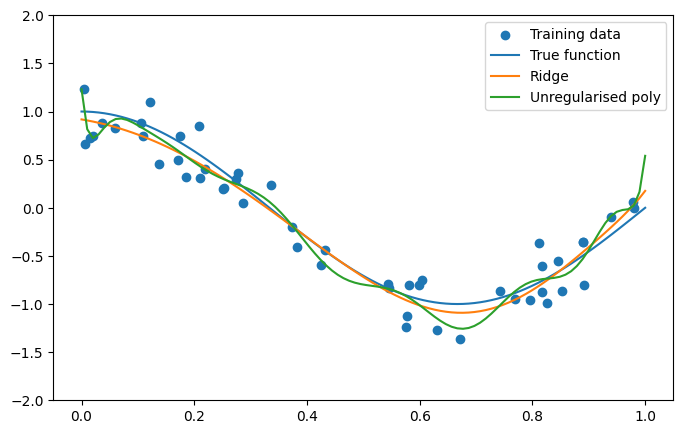

In [20]:
plt.figure(figsize=[8, 5])
plt.scatter(X, y, label='Training data')
plt.plot(X_curve, y_curve, label='True function')
plt.plot(X_curve, ridge_curve, label='Ridge')
plt.plot(X_curve, linear_poly_curve, label='Unregularised poly')
plt.ylim(-2, 2)
plt.legend()
plt.show()

### Calculating performance metrics

In [21]:
score('Ridge Poly', ridge_train_prediction, ridge_test_prediction)

,Model,R-squared train,R-squared test,RMSE train,RMSE test,MAE train,MAE test
0,Linear,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
1,Linear Poly,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
2,Poly degree 1,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
3,Poly degree 5,0.929641,0.912008,0.189898,0.207545,0.158424,0.168108
4,Poly degree 10,0.930361,0.912651,0.188924,0.206785,0.158208,0.166799
5,Poly degree 15,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
6,Poly degree 30,0.943608,-52.626507,0.170008,5.123642,0.132354,0.812184
7,Ridge Poly,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748


### Ridge with different lambdas

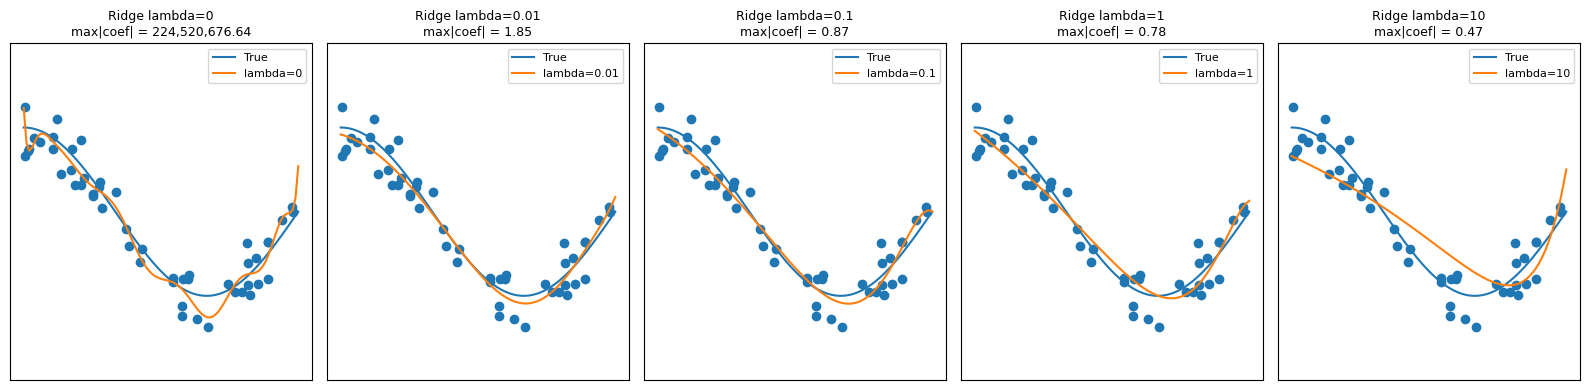

In [22]:
lambda_list = [0, 0.01, 0.1, 1, 10]

plt.figure(figsize=(16, 4))

for i, lambdai in enumerate(lambda_list):
    ax = plt.subplot(1, len(lambda_list), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    model = poly_ridge(alpha=lambdai)
    model.fit(X.reshape(-1, 1), y)

    name = f'Ridge lambda={lambdai}'
    score(name, model.predict(X.reshape(-1, 1)), model.predict(X_test.reshape(-1, 1)))
    record_coefs(name, model)

    plt.scatter(X, y)
    plt.plot(X_curve, y_curve, label='True')
    plt.plot(X_curve, model.predict(X_curve.reshape(-1, 1)), label=f'lambda={lambdai}')
    plt.ylim(-2, 2)
    plt.legend(fontsize=8)
    plt.title(f'Ridge lambda={lambdai}\nmax|coef| = {np.abs(model.steps[-1][1].coef_).max():,.2f}',
              fontsize=9)

plt.tight_layout()
plt.show()

### Performance Metrics

In [23]:
pd.DataFrame(scores.values())

,Model,R-squared train,R-squared test,RMSE train,RMSE test,MAE train,MAE test
0,Linear,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
1,Linear Poly,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
2,Poly degree 1,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
3,Poly degree 5,0.929641,0.912008,0.189898,0.207545,0.158424,0.168108
4,Poly degree 10,0.930361,0.912651,0.188924,0.206785,0.158208,0.166799
5,Poly degree 15,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
6,Poly degree 30,0.943608,-52.626507,0.170008,5.123642,0.132354,0.812184
7,Ridge Poly,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748
8,Ridge lambda=0,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
9,Ridge lambda=0.01,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748


**The Verdict: A Robust Model**

The Ridge model captures the true signal (the smooth cycle) while ignoring the extreme,
noisy wiggles.

Look at what lambda does across the five panels. At `lambda=0` there is no penalty at all,
so this is exactly the unregularised model from Part 3 - same coefficients, same test score.
A small penalty is enough to collapse the largest coefficient from 1.25 billion to 1.85, and
the test score jumps from 0.891 back to 0.912. Push lambda too far and the model becomes too rigid
and underfits.

It is not "perfect" on the training data, but it is robust. We traded a little
backtest-perfection for a lot of real-world stability. That is a winning trade.

### Coefficients

In [24]:
pd.DataFrame(coef_rows.values()).fillna(0)

,Model,Intercept,X^1,X^2,X^3,X^4,X^5,X^6,X^7,X^8,X^9,X^10,X^11,X^12,X^13,X^14,X^15,X^16,X^17,X^18,X^19,X^20,X^21,X^22,X^23,X^24,X^25,X^26,X^27,X^28,X^29,X^30
0,Poly degree 1,0.695345,-1.774490,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,Poly degree 5,0.864012,0.252261,-10.107531,-4.094936,2.827181e+01,-1.503896e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,Poly degree 10,0.927473,-7.596701,186.523024,-2036.254510,1.101858e+04,-3.474565e+04,6.756455e+04,-8.199020e+04,6.047334e+04,-2.480059e+04,4.336516e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,Poly degree 15,1.231188,-66.577159,3137.977262,-68699.916824,8.688827e+05,-7.064507e+06,3.902050e+07,-1.512418e+08,4.193680e+08,-8.397485e+08,1.214279e+09,-1.254020e+09,9.008020e+08,-4.271289e+08,1.200760e+08,-1.514450e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,Poly degree 30,1.564457,-168.900183,12404.962276,-449202.486302,9.522198e+06,-1.288459e+08,1.170990e+09,-7.366512e+09,3.249894e+10,-9.996324e+10,2.068059e+11,-2.574387e+11,1.128789e+11,1.461165e+11,-1.656922e+11,-1.036802e+11,1.522100e+11,1.241715e+11,-1.068135e+11,-1.624316e+11,2.525420e+10,1.733495e+11,7.449138e+10,-1.316003e+11,-1.529924e+11,5.717390e+10,1.921562e+11,-1.042178e+10,-2.334179e+11,1.717430e+11,-3.808282e+10
5,Ridge lambda=0,-0.129711,-20.733091,970.194566,-19691.711562,2.296642e+05,-1.730961e+06,8.924985e+06,-3.251590e+07,8.528588e+07,-1.624483e+08,2.245207e+08,-2.225243e+08,1.539244e+08,-7.047868e+07,1.917684e+07,-2.345421e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,Ridge lambda=0.01,-0.129711,-0.305332,-1.849086,-0.046188,8.511949e-01,9.424086e-01,6.581511e-01,2.762289e-01,-6.021924e-02,-2.896206e-01,-3.956040e-01,-3.854801e-01,-2.778681e-01,-9.562591e-02,1.381281e-01,4.021539e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,Ridge lambda=0.1,-0.129711,-0.656927,-0.871191,-0.142760,3.101572e-01,4.591600e-01,4.258682e-01,3.096457e-01,1.726508e-01,4.918841e-02,-4.439712e-02,-1.025877e-01,-1.259982e-01,-1.184091e-01,-8.495449e-02,-3.106049e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,Ridge lambda=1,-0.129711,-0.777610,-0.428044,-0.085761,1.202160e-01,2.157774e-01,2.397322e-01,2.214998e-01,1.806352e-01,1.294805e-01,7.552387e-02,2.308403e-02,-2.554629e-02,-6.933685e-02,-1.080167e-01,-1.417484e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,Ridge lambda=10,-0.129711,-0.471293,-0.253204,-0.102791,-1.074448e-02,4.124453e-02,6.726954e-02,7.68

## Part 5: The Insight Tool (Lasso Regression - L1)

Lasso is another, powerful type of regularization. It also adds a penalty (the L1 norm), but
it has a unique and incredibly useful side-effect.

Lasso is an insight and feature selection tool. It drives some coefficients to **exactly**
zero, so the fitted model tells you which features it is actually using.

Imagine you have a credit model with 200 features. Lasso might keep only 15 of them. That is
incredibly valuable for explaining your model to a boss, a risk manager, or a bank regulator.

One caution to carry with you: *which* coefficients get zeroed depends on the data and on
lambda. Where two features are strongly correlated, Lasso tends to keep one and drop the
other more or less arbitrarily, and a small change in the data can flip which one survives.
A zero coefficient is not proof that a variable does not matter.

### Library Import

In [25]:
from sklearn.linear_model import Lasso

### Building the pipeline

Same structure as Ridge, with two additions.

`max_iter` is raised because Lasso is solved by coordinate descent, and the polynomial design
matrix here is severely ill-conditioned (its condition number is about 2 x 10^11, since
`x`, `x^2`, `x^3` ... are all nearly the same shape on [0, 1]). At the default 1000 iterations
scikit-learn stops early and prints a `ConvergenceWarning`. Note that scaling alone does not
fix this - the collinearity is real, not a units problem.

In [26]:
def poly_lasso(alpha, degree=15):
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Lasso(alpha=alpha, max_iter=100000),
    )

In [27]:
lasso = poly_lasso(alpha=0.001)
lasso.fit(X.reshape(-1, 1), y)

lasso_train_prediction = lasso.predict(X.reshape(-1, 1))
lasso_test_prediction = lasso.predict(X_test.reshape(-1, 1))
lasso_curve = lasso.predict(X_curve.reshape(-1, 1))

lasso_coefs = lasso.steps[-1][1].coef_
print(f"{np.sum(lasso_coefs == 0)} of {len(lasso_coefs)} coefficients are exactly zero")

9 of 15 coefficients are exactly zero


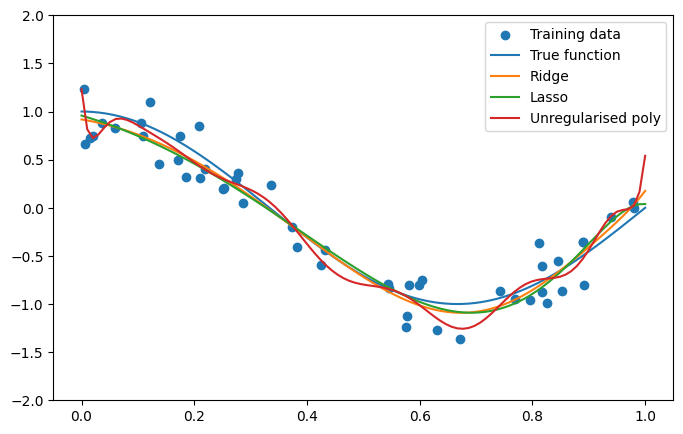

In [28]:
plt.figure(figsize=[8, 5])
plt.scatter(X, y, label='Training data')
plt.plot(X_curve, y_curve, label='True function')
plt.plot(X_curve, ridge_curve, label='Ridge')
plt.plot(X_curve, lasso_curve, label='Lasso')
plt.plot(X_curve, linear_poly_curve, label='Unregularised poly')
plt.ylim(-2, 2)
plt.legend()
plt.show()

### Calculating performance metrics

In [29]:
score('Lasso Poly', lasso_train_prediction, lasso_test_prediction)

,Model,R-squared train,R-squared test,RMSE train,RMSE test,MAE train,MAE test
0,Linear,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
1,Linear Poly,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
2,Poly degree 1,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
3,Poly degree 5,0.929641,0.912008,0.189898,0.207545,0.158424,0.168108
4,Poly degree 10,0.930361,0.912651,0.188924,0.206785,0.158208,0.166799
5,Poly degree 15,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
6,Poly degree 30,0.943608,-52.626507,0.170008,5.123642,0.132354,0.812184
7,Ridge Poly,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748
8,Ridge lambda=0,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
9,Ridge lambda=0.01,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748


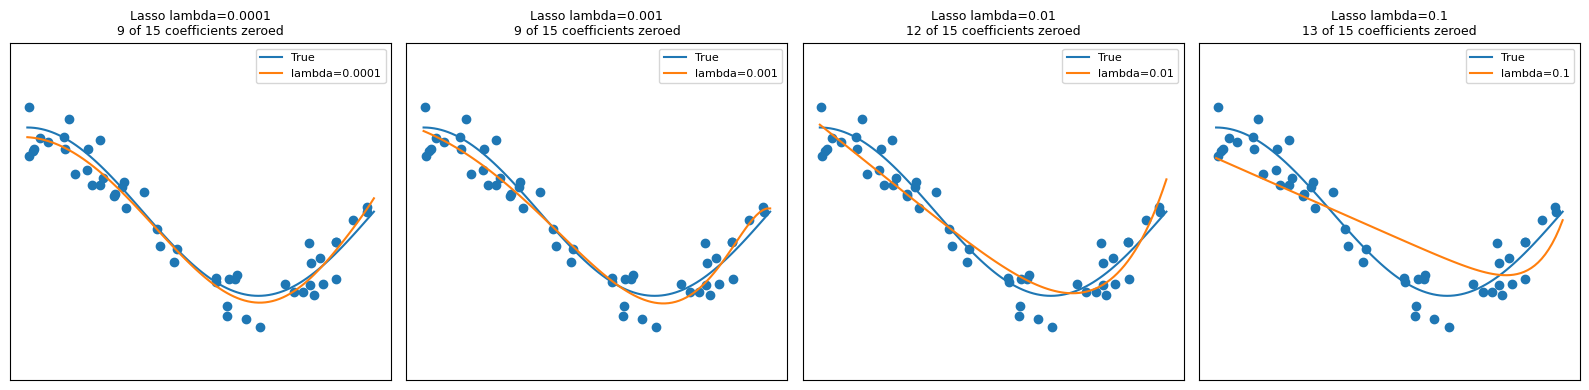

In [30]:
lambda_list = [0.0001, 0.001, 0.01, 0.1]

plt.figure(figsize=(16, 4))

for i, lambdai in enumerate(lambda_list):
    ax = plt.subplot(1, len(lambda_list), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    model = poly_lasso(alpha=lambdai)
    model.fit(X.reshape(-1, 1), y)

    name = f'Lasso lambda={lambdai}'
    score(name, model.predict(X.reshape(-1, 1)), model.predict(X_test.reshape(-1, 1)))
    record_coefs(name, model)

    coefs = model.steps[-1][1].coef_
    plt.scatter(X, y)
    plt.plot(X_curve, y_curve, label='True')
    plt.plot(X_curve, model.predict(X_curve.reshape(-1, 1)), label=f'lambda={lambdai}')
    plt.ylim(-2, 2)
    plt.legend(fontsize=8)
    plt.title(f'Lasso lambda={lambdai}\n{np.sum(coefs == 0)} of {len(coefs)} coefficients zeroed',
              fontsize=9)

plt.tight_layout()
plt.show()

### Performance Metrics

In [31]:
pd.DataFrame(scores.values())

,Model,R-squared train,R-squared test,RMSE train,RMSE test,MAE train,MAE test
0,Linear,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
1,Linear Poly,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
2,Poly degree 1,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
3,Poly degree 5,0.929641,0.912008,0.189898,0.207545,0.158424,0.168108
4,Poly degree 10,0.930361,0.912651,0.188924,0.206785,0.158208,0.166799
5,Poly degree 15,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
6,Poly degree 30,0.943608,-52.626507,0.170008,5.123642,0.132354,0.812184
7,Ridge Poly,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748
8,Ridge lambda=0,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
9,Ridge lambda=0.01,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748


**The Verdict: An Interpretable Model**

The Lasso model also gives us a smooth, robust curve, and its test score is competitive with
Ridge.

Now look at the coefficients in the table below. Lasso has set most of the fifteen polynomial
terms to **exactly 0.0** - not "small", not "1e-9", but zero. It has effectively turned those
features off, leaving a simpler model that a human can read.

Compare that with the Ridge row directly above it: every one of the fifteen Ridge
coefficients is non-zero. Ridge shrank them, Lasso selected among them. That difference is
the whole reason both exist.

### Coefficients

In [32]:
pd.DataFrame(coef_rows.values()).fillna(0)

,Model,Intercept,X^1,X^2,X^3,X^4,X^5,X^6,X^7,X^8,X^9,X^10,X^11,X^12,X^13,X^14,X^15,X^16,X^17,X^18,X^19,X^20,X^21,X^22,X^23,X^24,X^25,X^26,X^27,X^28,X^29,X^30
0,Poly degree 1,0.695345,-1.774490,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,Poly degree 5,0.864012,0.252261,-10.107531,-4.094936,2.827181e+01,-1.503896e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,Poly degree 10,0.927473,-7.596701,186.523024,-2036.254510,1.101858e+04,-3.474565e+04,6.756455e+04,-8.199020e+04,6.047334e+04,-2.480059e+04,4.336516e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,Poly degree 15,1.231188,-66.577159,3137.977262,-68699.916824,8.688827e+05,-7.064507e+06,3.902050e+07,-1.512418e+08,4.193680e+08,-8.397485e+08,1.214279e+09,-1.254020e+09,9.008020e+08,-4.271289e+08,1.200760e+08,-1.514450e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,Poly degree 30,1.564457,-168.900183,12404.962276,-449202.486302,9.522198e+06,-1.288459e+08,1.170990e+09,-7.366512e+09,3.249894e+10,-9.996324e+10,2.068059e+11,-2.574387e+11,1.128789e+11,1.461165e+11,-1.656922e+11,-1.036802e+11,1.522100e+11,1.241715e+11,-1.068135e+11,-1.624316e+11,2.525420e+10,1.733495e+11,7.449138e+10,-1.316003e+11,-1.529924e+11,5.717390e+10,1.921562e+11,-1.042178e+10,-2.334179e+11,1.717430e+11,-3.808282e+10
5,Ridge lambda=0,-0.129711,-20.733091,970.194566,-19691.711562,2.296642e+05,-1.730961e+06,8.924985e+06,-3.251590e+07,8.528588e+07,-1.624483e+08,2.245207e+08,-2.225243e+08,1.539244e+08,-7.047868e+07,1.917684e+07,-2.345421e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,Ridge lambda=0.01,-0.129711,-0.305332,-1.849086,-0.046188,8.511949e-01,9.424086e-01,6.581511e-01,2.762289e-01,-6.021924e-02,-2.896206e-01,-3.956040e-01,-3.854801e-01,-2.778681e-01,-9.562591e-02,1.381281e-01,4.021539e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,Ridge lambda=0.1,-0.129711,-0.656927,-0.871191,-0.142760,3.101572e-01,4.591600e-01,4.258682e-01,3.096457e-01,1.726508e-01,4.918841e-02,-4.439712e-02,-1.025877e-01,-1.259982e-01,-1.184091e-01,-8.495449e-02,-3.106049e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,Ridge lambda=1,-0.129711,-0.777610,-0.428044,-0.085761,1.202160e-01,2.157774e-01,2.397322e-01,2.214998e-01,1.806352e-01,1.294805e-01,7.552387e-02,2.308403e-02,-2.554629e-02,-6.933685e-02,-1.080167e-01,-1.417484e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,Ridge lambda=10,-0.129711,-0.471293,-0.253204,-0.102791,-1.074448e-02,4.124453e-02,6.726954e-02,7.68

## Part 6: Choosing lambda Properly

Every lambda in this notebook so far was picked by hand, by looking at the charts. That is
fine for teaching and unacceptable in practice - we chose it after seeing how it performed.

The honest procedure is cross-validation on the **training set only**: split the training data
into folds, fit on some and validate on the rest, and let the average validation error choose
lambda. The test set stays sealed until the very end.

Because the whole pipeline sits inside `GridSearchCV`, the polynomial expansion and the scaler
are refitted on each fold, so no fold can leak into another.

In [33]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(
    poly_ridge(alpha=1.0),                              # pipeline; alpha is overwritten below
    {'ridge__alpha': np.logspace(-4, 3, 50)},
    cv=5,
    scoring='neg_root_mean_squared_error',
)
search.fit(X.reshape(-1, 1), y)                         # training data only

best_alpha = search.best_params_['ridge__alpha']
print(f"cross-validation chose lambda = {best_alpha:.4f}")
print(f"   (we had hand-picked 0.01)")

score('Ridge (CV-tuned)',
      search.predict(X.reshape(-1, 1)),
      search.predict(X_test.reshape(-1, 1)))

cross-validation chose lambda = 0.0268
   (we had hand-picked 0.01)


,Model,R-squared train,R-squared test,RMSE train,RMSE test,MAE train,MAE test
0,Linear,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
1,Linear Poly,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
2,Poly degree 1,0.595801,0.592292,0.455154,0.446749,0.352749,0.369012
3,Poly degree 5,0.929641,0.912008,0.189898,0.207545,0.158424,0.168108
4,Poly degree 10,0.930361,0.912651,0.188924,0.206785,0.158208,0.166799
5,Poly degree 15,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
6,Poly degree 30,0.943608,-52.626507,0.170008,5.123642,0.132354,0.812184
7,Ridge Poly,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748
8,Ridge lambda=0,0.938389,0.891245,0.177701,0.230735,0.147496,0.189237
9,Ridge lambda=0.01,0.928762,0.911583,0.191081,0.208045,0.157177,0.168748


The tuned model lands at an RMSE of roughly 0.21 on the test set, against a noise floor of
0.20. In other words, cross-validation has taken us to within a couple of percent of the best
score any model could possibly achieve on this data - and it got there without ever looking at
the test set.

That is the workflow the final project expects.

## Final Verdict: From Engineering to Finance
In this notebook, we saw four types of models:

*   **The Too-Simple Model**: a straight line through a cycle. Consistently wrong (high bias).

*   **The Overfit Model**: Looked best on the training data, and at degree 30 scored a
    *negative* test R-squared. Dangerously unusable.

*   **The Ridge Model**: Gave us a stable and robust prediction. Ideal for managing correlated
    features and creating reliable forecasts.

*   **The Lasso Model**: Gave us an interpretable and simple prediction. Ideal for
    understanding what drives the model and explaining it to stakeholders.

Two habits to take away, because they are worth more than any single algorithm:

1.  **Judge every model on data it has never seen.** Every honest number in this notebook came
    from the held-out test sample, never from the training data.
2.  **Nothing beats the noise.** We simulated the data, so we know the noise had a standard
    deviation of 0.2 - and the best model above lands at an RMSE of about 0.21. That gap is
    irreducible error, and no amount of extra complexity removes it. With real data you never
    know where that floor is, which is exactly why a model that appears to beat it should
    worry you rather than please you.

This is the key lesson: in finance, we don't just want the model with the lowest error. We
want the model that is the most reliable, stable, and interpretable.

# Homework: Week 1 - The Overfitting Trap in Marketing ROI

## Dataset:
https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Advertising.csv

Load it with `pd.read_csv(url, index_col=0)`. The file carries an unnamed first column that
is just the row number - if you forget `index_col=0` you will silently train on it as a
feature.

## Part 1: The "Simple" Model (Baseline)
1.   **Split Your Data:** Before you do anything else, split your data into a training set and a test set using train_test_split. (Use a test_size=0.3 and random_state=1). You will use the training set to fit all your models and the test set to evaluate them.

2.   **Fit & Interpret:** Fit a simple LinearRegression using only the three original features (TV, Radio, Newspaper).

3.   **Write Down Coefficients and Performance metrics:** Note the coefficients for TV, Radio, and Newspaper and its performance metrics on both train set and test set. This will be your baseline model.

## Part 2: The "Overly Complex" Model (The Trap)

1.   **Create Polynomial Features:** Use PolynomialFeatures (try degree=5) to create a new, high-dimensional training set. This will create many new features (e.g., TV^2, Radio^3, TV * Radio). Make sure to fit_transform on your training data and only .transform your test data.
2.   **Scale Your Features:** Use StandardScaler. fit_transform on the polynomial training data and just .transform on the polynomial test data. (This is critical for regularization to work.)
3.   **Fit the Overfit Model:** Fit a LinearRegression on this new, scaled, polynomial training set.
4.   **Check the Coefficients and Metrics:** Print the model.coef_ and calculate its performance metrics.

> Steps 1 and 2 are exactly what a `Pipeline` does for you, as we did in Parts 4 and 5. Do it
> by hand once so you can see the order, then use a pipeline for the rest.

### Question 1 (Observation):
* What do you observe about the coefficients? Are they large or small? Do they make any intuitive sense? What does this tell you about the risk of this model? (Hint: They will likely be huge and non-sensical, a classic sign of overfitting).
* Print the metrics for this complex model on the training set.
* Print the R-squared score for this same model on the test set.
* What do you observe? What does the difference between these two scores (and the baseline score from Part 1) tell you about this model? Is this a good model?

## Part 3: The Regularization Fix (Ridge & Lasso)
Now, let's fix the model from Part 2.
1.   Fit Ridge: Fit a Ridge model on the same scaled, polynomial training data.
2.   Fit Lasso: Fit a Lasso model on the same scaled, polynomial training data.

### Question 2 (Analysis & Performance):
* What do you observe about the coefficients from the two new models now? Are they still large or small? Make some comments about the changes.
* Look at the coefficients from your Lasso model. How many features did it set to zero? What does this tell you about the 'true' drivers of sales?
* What is the performance metrics for your Ridge model on the train set and test set?
* What is the performance metrics for your Lasso model on the train set and test set?
* How do these scores compare to the 'overfit' model's test score? What does this prove about the value of regularization?

### Question 3 (The Verdict):
In the end, after trying a simple model, an overfit complex model, and two regularized models, what is your final recommendation to the CMO? Which channels (TV, Radio, Newspaper) are the most reliable drivers of sales?

### Question 4 (Choosing lambda):
You picked the Ridge and Lasso `alpha` by hand. Use `GridSearchCV` with `cv=5` on the
*training set only* to choose it properly, then report the test score of the tuned model.
Did the tuned model beat your hand-picked one?